# ⚽ Football Intelligence Dashboard - Modeling: Predicting Player Market Value

**Goal:** Predict a player's `value_eur` from their attributes, and answer a design question from the EDA phase — does `wage_eur` actually help predict value, or is it redundant once we already know how good a player is?

We'll build **two feature sets** (with and without wage) and **two algorithms** (Linear Regression as a baseline, Random Forest as the stronger model), then compare all four.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
sns.set_palette('husl')

In [2]:
# Load our dataset (same cleaning as 02_eda.ipynb)
df = pd.read_csv("../data/cleaned/fifa24_top5_leagues.csv")

outfield_stats = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
df[outfield_stats] = df[outfield_stats].fillna(0)
df['release_clause_eur'] = df['release_clause_eur'].fillna(0)

print(f"Players: {len(df)}")
print(f"Missing values: {df.isnull().sum().sum()}")

Players: 3467
Missing values: 0


## Step 1: Check the Target Variable's Distribution

Before modeling, always look at how your target (`value_eur`) is distributed. Regression models like Linear Regression assume errors are roughly symmetric — if the target is heavily skewed (a few huge outliers, lots of small values), the model will focus on minimizing error for the expensive players and underperform on typical ones.

Market values for footballers are a classic case: most players are worth a few million euros, but a handful (Mbappé, Haaland) are worth 100M+. That's exactly the kind of skew we need to check for.

Skewness of value_eur: 4.27
Skewness of log1p(value_eur): 0.14


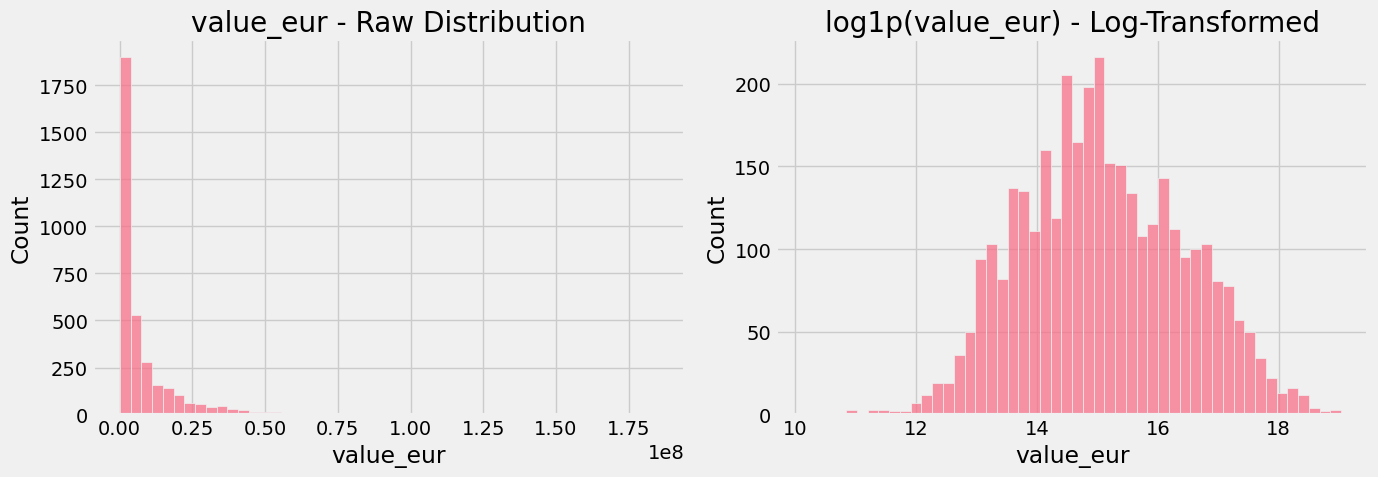

In [3]:
print(f"Skewness of value_eur: {df['value_eur'].skew():.2f}")
print(f"Skewness of log1p(value_eur): {np.log1p(df['value_eur']).skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['value_eur'], bins=50, ax=axes[0])
axes[0].set_title('value_eur - Raw Distribution')
sns.histplot(np.log1p(df['value_eur']), bins=50, ax=axes[1])
axes[1].set_title('log1p(value_eur) - Log-Transformed')
plt.tight_layout()
plt.show()

**Finding:** Raw `value_eur` has a skewness of **4.27** (heavily right-skewed — a few superstar transfers stretch the tail). After a `log1p` transform, skewness drops to **0.14**, close to a normal distribution.

**What we'll do:** Train the model to predict `log1p(value_eur)` instead of raw euros, then convert predictions back with `expm1()` for interpretable evaluation. This is standard practice whenever a target spans several orders of magnitude — money, population, income, etc.

## Step 2: Build the Two Feature Sets

Per our earlier decision, we're building **two versions** of the model:
- **Model A** — includes `wage_eur` as a feature
- **Model B** — excludes it, so value is predicted purely from playing ability and profile

Both include the on-pitch attributes from the Q3 correlation analysis, plus `position_group` (from Q7) since we already saw position affects earning power independent of skill.

In [4]:
# Position group (same mapping as Q7)
df['primary_position'] = df['player_positions'].apply(lambda x: x.split(',')[0].strip())
position_map = {
    'GK': 'Goalkeeper',
    'CB': 'Defender', 'LB': 'Defender', 'RB': 'Defender', 'LWB': 'Defender', 'RWB': 'Defender',
    'CDM': 'Midfielder', 'CM': 'Midfielder', 'CAM': 'Midfielder', 'LM': 'Midfielder', 'RM': 'Midfielder',
    'ST': 'Forward', 'CF': 'Forward', 'LW': 'Forward', 'RW': 'Forward', 'LF': 'Forward', 'RF': 'Forward'
}
df['position_group'] = df['primary_position'].map(position_map)

base_features = ['overall', 'potential', 'age', 'international_reputation',
                  'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
                  'weak_foot', 'skill_moves']

# One-hot encode position (drop_first avoids a redundant column)
pos_dummies = pd.get_dummies(df['position_group'], prefix='pos', drop_first=True)

X_base = pd.concat([df[base_features], pos_dummies], axis=1)
y = np.log1p(df['value_eur'])

X_model_a = pd.concat([X_base, df[['wage_eur']]], axis=1)   # with wage
X_model_b = X_base.copy()                                    # without wage

print(f"Model A features ({X_model_a.shape[1]}): {list(X_model_a.columns)}")
print(f"Model B features ({X_model_b.shape[1]}): {list(X_model_b.columns)}")

Model A features (16): ['overall', 'potential', 'age', 'international_reputation', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'weak_foot', 'skill_moves', 'pos_Forward', 'pos_Goalkeeper', 'pos_Midfielder', 'wage_eur']
Model B features (15): ['overall', 'potential', 'age', 'international_reputation', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'weak_foot', 'skill_moves', 'pos_Forward', 'pos_Goalkeeper', 'pos_Midfielder']


## Step 3: Train/Test Split

We hold out 20% of players as a **test set** the model never sees during training. This is how we check whether the model actually learned generalizable patterns, versus just memorizing the training data (**overfitting**). `random_state=42` just makes the split reproducible — you get the same split every time you run this.

In [5]:
def evaluate(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rows = []
    fitted = {}
    for model_name, model in [('Linear Regression', LinearRegression()),
                               ('Random Forest', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]:
        model.fit(X_train, y_train)
        pred_log = model.predict(X_test)

        y_test_real = np.expm1(y_test)
        pred_real = np.expm1(pred_log)

        rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
        mae = mean_absolute_error(y_test_real, pred_real)
        r2 = r2_score(y_test_real, pred_real)

        rows.append({'Feature set': label, 'Model': model_name,
                      'RMSE (EUR)': round(rmse), 'MAE (EUR)': round(mae), 'R2': round(r2, 4)})
        fitted[model_name] = model
    return rows, fitted

rows_a, models_a = evaluate(X_model_a, y, 'Model A (with wage_eur)')
rows_b, models_b = evaluate(X_model_b, y, 'Model B (without wage_eur)')

results_df = pd.DataFrame(rows_a + rows_b)
print(results_df.to_string(index=False))

               Feature set             Model  RMSE (EUR)  MAE (EUR)     R2
   Model A (with wage_eur) Linear Regression     9468126    2036706 0.6856
   Model A (with wage_eur)     Random Forest     2830770     697036 0.9719
Model B (without wage_eur) Linear Regression     8177701    1906885 0.7655
Model B (without wage_eur)     Random Forest     2676460     679177 0.9749


## 📌 Finding - Model Comparison

**Random Forest massively outperforms Linear Regression** — it explains ~97% of the variance in player value vs ~69-77% for a straight line (R²). That's expected: value doesn't move linearly with skill (a small gap in `overall` between a good and a great player often means a huge jump in value), and Random Forest captures those non-linear jumps and interactions naturally.

**Surprising result:** Model B (without `wage_eur`) is essentially tied with — even marginally better than — Model A (R² 0.9749 vs 0.9719 for Random Forest). Despite wage having the *strongest single correlation* with value back in Q3 (0.82), it adds almost nothing once the model already has skill ratings.

*RMSE = average prediction error, penalizes big misses more. MAE = average prediction error, treats all misses equally. R² = proportion of variance explained; 1.0 is a perfect fit.*

## Step 4: Feature Importance — Why Does Model B Match Model A?

Correlation (Q3) only looks at one variable at a time against the target. **Feature importance** in a Random Forest measures how much each feature actually reduces prediction error *once all the other features are already in the model* — it captures redundancy that plain correlation can't see.

Top 8 features - Model A (with wage_eur):
overall      0.796022
potential    0.142961
age          0.047107
dribbling    0.002645
pace         0.002524
shooting     0.002224
wage_eur     0.001990
passing      0.001303
dtype: float64

Top 8 features - Model B (without wage_eur):
overall      0.796520
potential    0.143380
age          0.047467
dribbling    0.002865
pace         0.002619
shooting     0.002291
passing      0.001434
defending    0.000860
dtype: float64


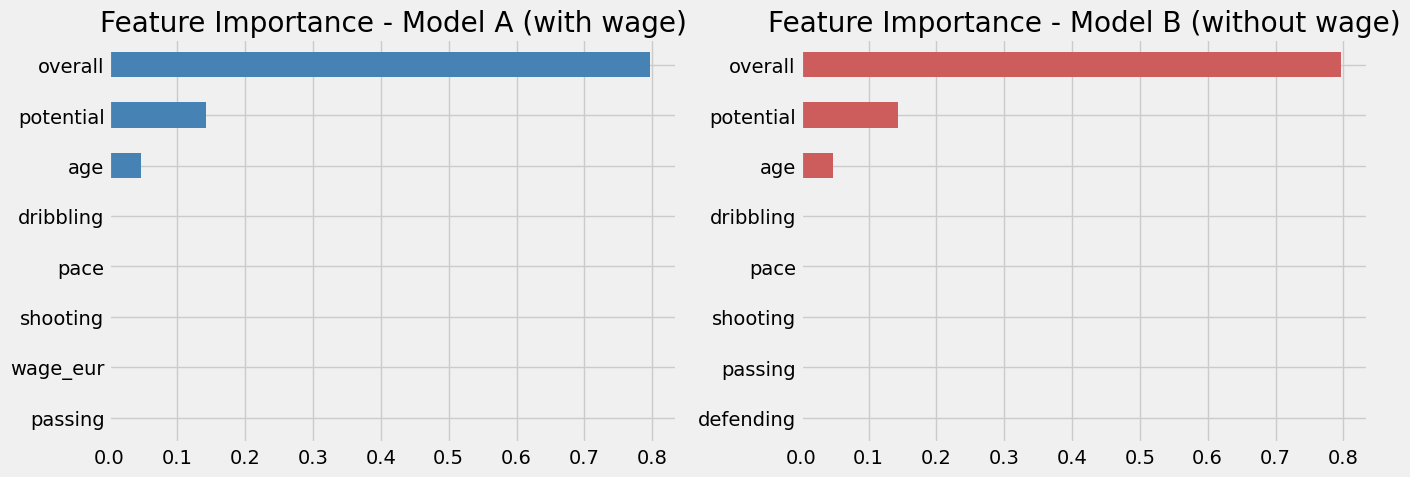

In [6]:
importance_a = pd.Series(models_a['Random Forest'].feature_importances_, index=X_model_a.columns).sort_values(ascending=False)
importance_b = pd.Series(models_b['Random Forest'].feature_importances_, index=X_model_b.columns).sort_values(ascending=False)

print("Top 8 features - Model A (with wage_eur):")
print(importance_a.head(8))
print()
print("Top 8 features - Model B (without wage_eur):")
print(importance_b.head(8))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importance_a.head(8).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance - Model A (with wage)')
importance_b.head(8).sort_values().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Feature Importance - Model B (without wage)')
plt.tight_layout()
plt.show()

## 📌 Finding - Feature Importance

`overall` dominates both models (~80% of importance), followed by `potential` (~14%) and `age` (~5%) — together these three account for over 98% of the model's predictive power. Every other feature, including `wage_eur` itself (importance ≈ 0.002), barely moves the needle.

**Why wage looked important in Q3 but isn't here:** correlation measures a raw, one-to-one relationship — wage is high because overall/potential are high, so it *looks* predictive on its own. But once the model already knows `overall` and `potential`, wage is redundant information — it isn't telling the model anything new. This is a classic case of **multicollinearity**: two features carrying overlapping information, where only one gets 'credit' in a multivariate model.

**Conclusion for the project:** Model B — Random Forest without `wage_eur` — is the better choice. It's simpler (one fewer input, and one that isn't always public knowledge anyway) and performs just as well. A player's market value is, in short, almost entirely explained by **how good they are right now (`overall`) and how good they could become (`potential`)**, with age acting as a moderate tiebreaker.

## Step 5: Cross-Validation — Is This Result Stable?

A single 80/20 train/test split can get lucky or unlucky depending on which players happen to land in the test set. **K-fold cross-validation** guards against that: we split the data into 5 folds, train on 4 and test on the 5th, and rotate which fold is held out — so every player gets predicted exactly once by a model that never saw them during training, and we get 5 independent R² estimates instead of just one.

In [9]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for model_name, model_cls in [('Linear Regression', LinearRegression),
                               ('Random Forest', lambda: RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1))]:
    r2_scores, rmse_scores = [], []
    for train_idx, test_idx in kf.split(X_model_b):
        X_tr, X_te = X_model_b.iloc[train_idx], X_model_b.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        m = model_cls()
        m.fit(X_tr, y_tr)
        pred = m.predict(X_te)
        y_te_real, pred_real = np.expm1(y_te), np.expm1(pred)
        r2_scores.append(r2_score(y_te_real, pred_real))
        rmse_scores.append(np.sqrt(mean_squared_error(y_te_real, pred_real)))
    r2_scores, rmse_scores = np.array(r2_scores), np.array(rmse_scores)
    cv_results.append({'Model': model_name, 'R2 mean': round(r2_scores.mean(),4),
                        'R2 std': round(r2_scores.std(),4), 'RMSE mean (EUR)': round(rmse_scores.mean())})
    print(f"{model_name}: R² per fold = {np.round(r2_scores,4)}")

print()
print(pd.DataFrame(cv_results).to_string(index=False))

Linear Regression: R² per fold = [0.7655 0.9317 0.8009 0.9027 0.4331]


Random Forest: R² per fold = [0.9744 0.9921 0.989  0.9728 0.978 ]

            Model  R2 mean  R2 std  RMSE mean (EUR)
Linear Regression   0.7668  0.1779          6827736
    Random Forest   0.9813  0.0078          2020029


## 📌 Finding - Cross-Validation

**Random Forest is not just accurate, it's stable:** R² = **0.981 ± 0.008** across 5 folds — every single fold lands between 0.97 and 0.99. This is a materially stronger validation story than a single train/test split, which could report anywhere in that range by chance alone.

**Linear Regression, by contrast, is unstable:** its R² swings from **0.43 to 0.93** depending on which fold is held out. That's not just "a worse model" — it's a model whose reported performance depends heavily on luck in the train/test split, which would have been invisible if we'd only run the original single 80/20 split. Cross-validation is what surfaces this.

## Step 6: Error Analysis — Where Does the Model Get It Wrong?

A headline R² of 0.98 hides where the remaining 2% of error is concentrated. Using out-of-fold predictions (via the 5-fold split above, every player is predicted by a model that never trained on them) we can look at *individual* prediction errors and check for patterns — that's more informative than the aggregate number, and it's the kind of check that distinguishes a genuinely validated model from a model that just has a good headline metric.

In [10]:
from sklearn.model_selection import cross_val_predict

rf_final = RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)
oof_pred_log = cross_val_predict(rf_final, X_model_b, y, cv=kf, n_jobs=-1)

df['predicted_value'] = np.expm1(oof_pred_log)
df['residual'] = df['value_eur'] - df['predicted_value']  # positive = model predicted too LOW
df['abs_pct_error'] = (df['residual'].abs() / df['value_eur']) * 100

print(f"Overall mean absolute % error: {df['abs_pct_error'].mean():.1f}%")
print(f"Overall median absolute % error: {df['abs_pct_error'].median():.1f}%")

print("\nTop 5 UNDERESTIMATED (model predicted too LOW):")
print(df.nlargest(5, 'residual')[['short_name','age','overall','potential','position_group','value_eur','predicted_value']].to_string(index=False))

print("\nTop 5 OVERESTIMATED (model predicted too HIGH):")
print(df.nsmallest(5, 'residual')[['short_name','age','overall','potential','position_group','value_eur','predicted_value']].to_string(index=False))

Overall mean absolute % error: 5.3%
Overall median absolute % error: 3.1%

Top 5 UNDERESTIMATED (model predicted too LOW):
 short_name  age  overall  potential position_group   value_eur  predicted_value
 E. Haaland   22       91         94        Forward 185000000.0     1.335846e+08
  K. Mbappé   24       91         94        Forward 181500000.0     1.431532e+08
 J. Musiala   20       86         93     Midfielder 134500000.0     1.082037e+08
 V. Osimhen   24       88         91        Forward 126500000.0     1.003118e+08
F. Valverde   24       88         92     Midfielder 130500000.0     1.054985e+08

Top 5 OVERESTIMATED (model predicted too HIGH):
    short_name  age  overall  potential position_group  value_eur  predicted_value
R. Lewandowski   34       90         90        Forward 58000000.0     9.614801e+07
 M. ter Stegen   31       89         89     Goalkeeper 54500000.0     7.196985e+07
       Rodrygo   22       85         91        Forward 86500000.0     9.982645e+07
      M. N

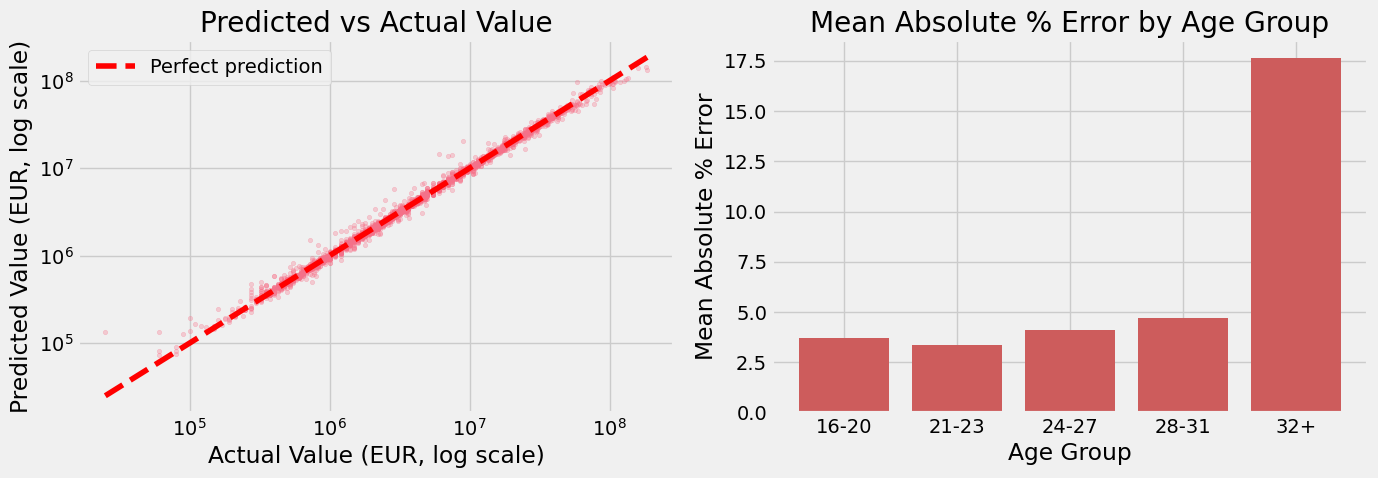

In [11]:
df['age_bucket'] = pd.cut(df['age'], bins=[15,20,23,27,31,45], labels=['16-20','21-23','24-27','28-31','32+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual scatter (log scale, since values span 3 orders of magnitude)
axes[0].scatter(df['value_eur'], df['predicted_value'], alpha=0.3, s=10)
lims = [df['value_eur'].min(), df['value_eur'].max()]
axes[0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Actual Value (EUR, log scale)')
axes[0].set_ylabel('Predicted Value (EUR, log scale)')
axes[0].set_title('Predicted vs Actual Value')
axes[0].legend()

# Error by age bucket
age_err = df.groupby('age_bucket', observed=True)['abs_pct_error'].mean()
axes[1].bar(age_err.index.astype(str), age_err.values, color='indianred')
axes[1].set_title('Mean Absolute % Error by Age Group')
axes[1].set_ylabel('Mean Absolute % Error')
axes[1].set_xlabel('Age Group')

plt.tight_layout()
plt.show()

## 📌 Finding - Error Analysis

**Overall the model is tight** — median absolute error is just **3.1%** of a player's value, and mean absolute error is 5.3% (pulled up by a smaller set of harder cases).

**Where it gets it wrong falls into three clear patterns:**

1. **Elite young superstars are underpriced by the model.** Haaland, Mbappé, Musiala, Vinícius Jr. — the model predicts €20–50M *below* their actual value. These are players whose market value carries a "star power" premium (global brand, marketing value, proven big-game impact) beyond what attribute ratings alone capture.

2. **Aging veterans are overpriced by the model, badly.** Error jumps from ~3-5% for players under 32 to **17.6%** for players 32 and older — by far the single strongest pattern in the data. Lewandowski (34) is the single worst miss in the entire dataset: the model predicts €96M based on his stats, but he's actually valued at €58M. Stats alone don't capture the market's discount for age-related transfer risk, injury risk, and shortening contract horizons.

3. **Goalkeepers are the hardest position to price** — 10.9% mean error vs 4-5% for every outfield position. Four of the ten most-overestimated players in the whole dataset are aging goalkeepers (ter Stegen, Neuer, Oblak, Navas). With outfield attributes zeroed out for GKs, the model has far fewer meaningful signals to distinguish an elite keeper from an average one.

**What this means honestly:** the R²=0.98 headline is real, but it masks real, systematic blind spots — the model is good at pricing typical players in their prime, and specifically weak on reputation premiums, age-related decline, and goalkeepers. A production version of this model would benefit from an explicit age-decay feature and either a separate model for goalkeepers or GK-specific attributes.

## Next Steps

- Save the final Model B (Random Forest) for the dashboard
- Write up this comparison in the project README as the modeling section
- (Optional) Build a small Streamlit app where a user inputs a player's stats and gets a predicted value